# Inspect DeepCMorph Segmentation and Classification

In [3]:
import numpy as np

In [4]:
image_path = "/mnt/bulk-saturn/maralampert/genhist/data/test_tumor_zip/TCGA-3C-AALI-01Z-00-DX1.F6E9A5DF-D8FB-45CF-B4BD-C6B76294C291.b712aacbf58f47d612cb43986a2f97a21bcea971a4beb2070055f123940c1afd.zip"

In [5]:
label_path = "/mnt/bulk-saturn/maralampert/genhist/experiments/20260220_segmentation/TCGA-3C-AALI.zip"

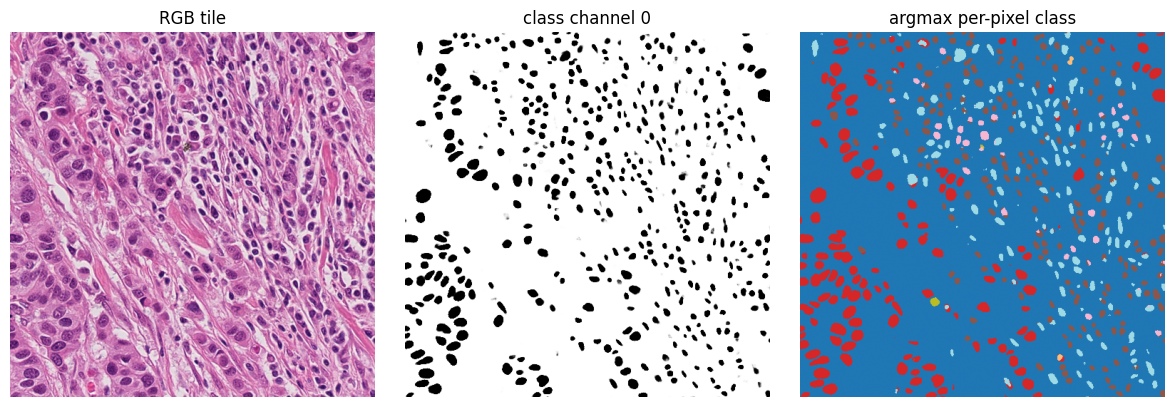

In [8]:
import zipfile
from io import BytesIO
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# pick a tile (first / random)
with zipfile.ZipFile(image_path, "r") as iz:
    image_files = [n for n in iz.namelist() if Path(n).suffix.lower() in {".png",".jpg",".jpeg",".tif",".tiff"}]
    img_name = image_files[0]  # or pick random.choice(image_files)
    img = Image.open(BytesIO(iz.read(img_name))).convert("RGB")

# find matching label inside the label zip (by stem or substring)
stem = Path(img_name).stem
with zipfile.ZipFile(label_path, "r") as lz:
    candidates = [n for n in lz.namelist() if stem in Path(n).stem]
    if not candidates:
        raise FileNotFoundError(f"No label matching {stem} in {label_path}")
    lab_name = candidates[0]
    lab_bytes = lz.read(lab_name)

# normalize to H,W,C if needed
if label.ndim == 3 and label.shape[0] <= 64:  # channel-first -> (C,H,W)
    label_hwc = np.transpose(label, (1, 2, 0))
else:
    label_hwc = label

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# 1) original tile
axs[0].imshow(img); axs[0].axis('off'); axs[0].set_title('RGB tile')

# 2) single channel (choose idx)
idx = 0
axs[1].imshow(label_hwc[..., idx], cmap='gray'); axs[1].axis('off')
axs[1].set_title(f'class channel {idx}')

# 3) argmax composite (per-pixel class index)
if label_hwc.ndim == 3:
    seg = np.argmax(label_hwc, axis=-1).astype(np.int32)
else:
    seg = (label_hwc > 0).astype(np.uint8)  # fallback
nclasses = seg.max() + 1
cmap = plt.get_cmap('tab20', nclasses)
axs[2].imshow(seg, cmap=cmap, vmin=0, vmax=max(1, nclasses-1)); axs[2].axis('off')
axs[2].set_title('argmax per-pixel class')

plt.tight_layout()
plt.show()